# Assignment 1: Store Sales Analysis & Prediction

**Dataset:** `sales_data.csv` — 366 days of daily store sales data (Jan 1 – Dec 31, 2024)

**Objective:**
1. Perform Exploratory Data Analysis (EDA)
2. Engineer features (lag, rolling averages)
3. Train a prediction model using last 30 days as the test set
4. Evaluate using MAE & RMSE
5. Predict next 7 days of sales
6. Provide 5 business insights

**Tools:** Python, pandas, numpy, matplotlib, seaborn, scikit-learn (all free, no paid APIs)

## Step 1: Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load & Inspect Data

In [19]:
# Load dataset
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (366, 3)
Date Range: 2024-01-01 to 2024-12-31

First 5 rows:


,Sales,Promotion,DayOfWeek
Date,,,
2024-01-01,204.21,0,1
2024-01-02,256.30,1,2
2024-01-03,216.38,0,3
2024-01-04,201.28,0,4
2024-01-05,182.48,0,5


In [20]:
# Data types and info
print("Data Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
df.describe()

Data Types:
Sales        float64
Promotion      int64
DayOfWeek      int64
dtype: object

Basic Statistics:


,Sales,Promotion,DayOfWeek
count,366.000000,366.000000,366.000000
mean,209.672104,0.193989,3.986339
std,27.362647,0.395962,2.006108
min,149.930000,0.000000,1.000000
25%,189.750000,0.000000,2.000000
50%,206.770000,0.000000,4.000000
75%,226.072500,0.000000,6.000000
max,286.290000,1.000000,7.000000


In [21]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\n No missing values found!" if df.isnull().sum().sum() == 0 else "\n⚠️ Missing values detected!")

Missing Values:
Sales        0
Promotion    0
DayOfWeek    0
dtype: int64

Total missing values: 0

 No missing values found!


## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Sales Over Time

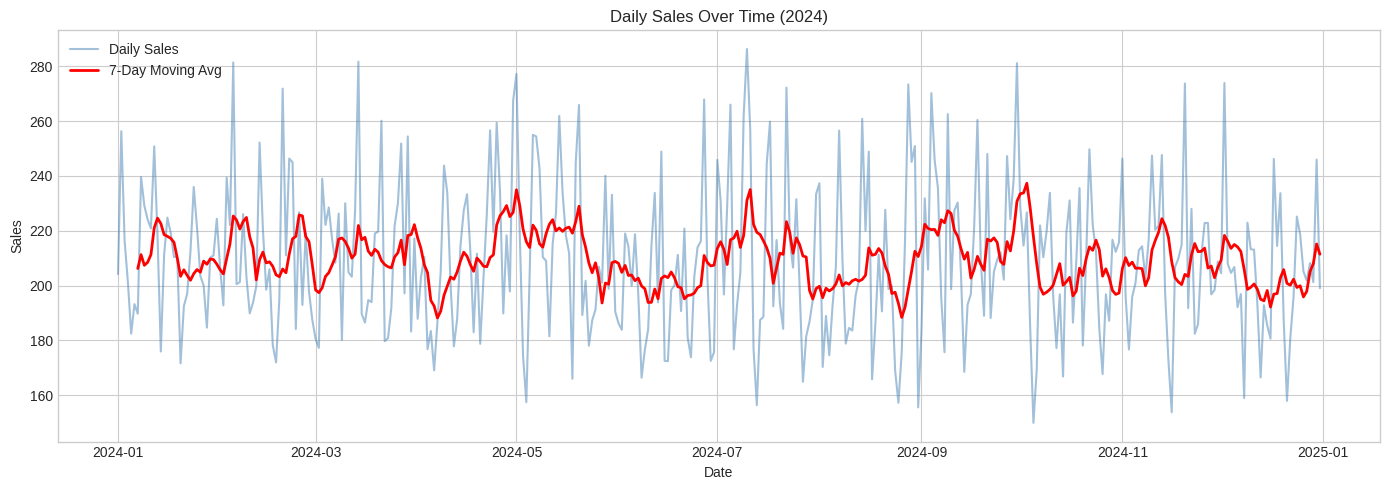

In [5]:
# Plot 1: Sales over time with 7-day moving average
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Sales'], alpha=0.5, label='Daily Sales', color='steelblue')
ax.plot(df.index, df['Sales'].rolling(7).mean(), color='red', linewidth=2, label='7-Day Moving Avg')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('Daily Sales Over Time (2024)')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Promotion vs Non-Promotion Sales

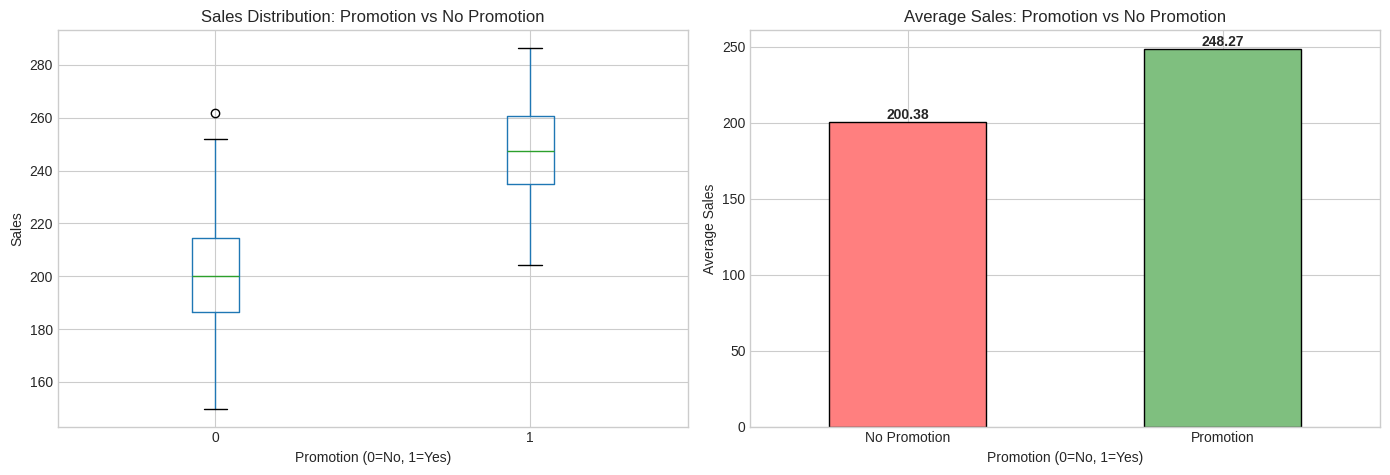

Promotion vs Non-Promotion Statistics:
             mean    std  count
Promotion                      
0          200.38  19.98    295
1          248.27  18.80     71

Promotion sales lift: 47.88 (23.9% increase)


In [6]:
# Plot 2: Promotion vs Non-Promotion sales comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='Sales', by='Promotion', ax=axes[0])
axes[0].set_title('Sales Distribution: Promotion vs No Promotion')
axes[0].set_xlabel('Promotion (0=No, 1=Yes)')
axes[0].set_ylabel('Sales')
plt.sca(axes[0])
plt.title('Sales Distribution: Promotion vs No Promotion')

# Bar chart with means
promo_stats = df.groupby('Promotion')['Sales'].agg(['mean', 'std', 'count'])
promo_stats['mean'].plot(kind='bar', ax=axes[1], color=['#ff7f7f', '#7fbf7f'], edgecolor='black')
axes[1].set_title('Average Sales: Promotion vs No Promotion')
axes[1].set_xlabel('Promotion (0=No, 1=Yes)')
axes[1].set_ylabel('Average Sales')
axes[1].set_xticklabels(['No Promotion', 'Promotion'], rotation=0)

# Add value labels on bars
for i, v in enumerate(promo_stats['mean']):
    axes[1].text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Print statistics
print("Promotion vs Non-Promotion Statistics:")
print(promo_stats.round(2))
print(f"\nPromotion sales lift: {promo_stats.loc[1, 'mean'] - promo_stats.loc[0, 'mean']:.2f} "
      f"({((promo_stats.loc[1, 'mean'] / promo_stats.loc[0, 'mean']) - 1) * 100:.1f}% increase)")

### 3.3 Sales by Day of Week

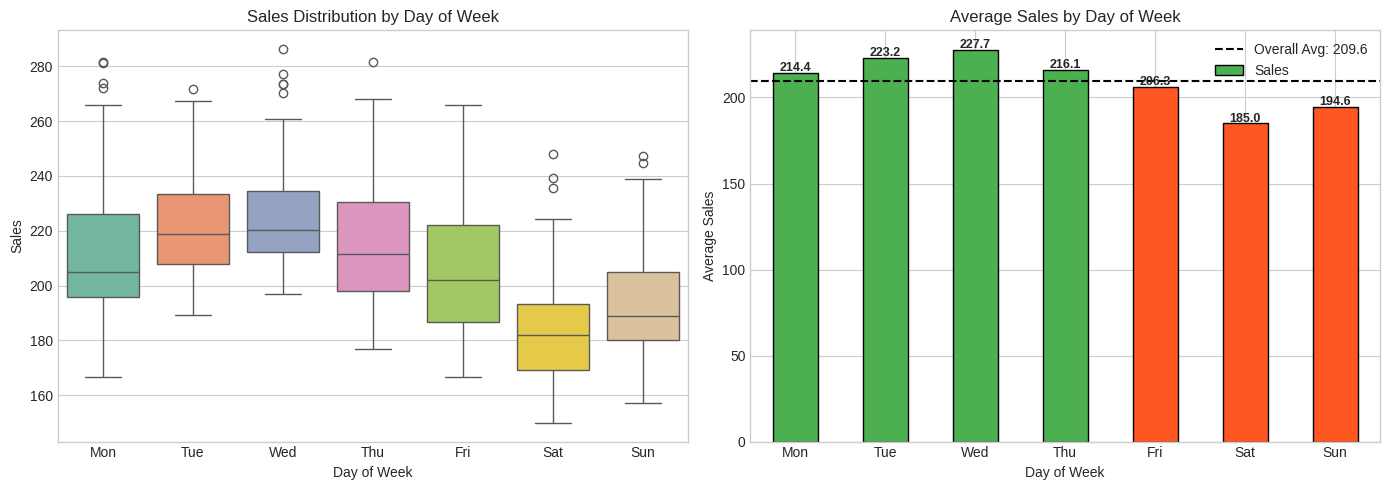

In [7]:
# Plot 3: Sales by Day of Week
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df['DayName'] = df['DayOfWeek'].map(day_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.boxplot(data=df, x='DayName', y='Sales', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Sales Distribution by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Sales')

# Bar chart with averages
day_avg = df.groupby('DayOfWeek')['Sales'].mean()
colors = ['#4CAF50' if v > day_avg.mean() else '#FF5722' for v in day_avg.values]
day_avg.index = [day_map[i] for i in day_avg.index]
day_avg.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].axhline(y=day_avg.mean(), color='black', linestyle='--', label=f'Overall Avg: {day_avg.mean():.1f}')
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Sales')
axes[1].set_xticklabels(day_avg.index, rotation=0)
axes[1].legend()

# Add value labels
for i, v in enumerate(day_avg.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Drop the helper column
df.drop('DayName', axis=1, inplace=True)

## Step 4: Feature Engineering

We create a rich set of features for our model:

**Lag Features (capture momentum/inertia):**
- **`lag_1`** — Previous day's sales (required by assignment)
- **`lag_7`** — Sales from 7 days ago (weekly seasonality)
- **`lag_14`** — Sales from 14 days ago (bi-weekly pattern)

**Rolling Average Features (capture trends):**
- **`rolling_7`** — 7-day rolling average (short-term trend)
- **`rolling_30`** — 30-day rolling average (long-term trend)

**Calendar Features (capture cyclical patterns):**
- **`Month`** — Month of the year (1-12)
- **`DayOfMonth`** — Day within the month (1-31)
- **`IsWeekend`** — Binary flag (1 if Saturday/Sunday, else 0)

**Interaction Feature:**
- **`Promo_Weekend`** — Promotion × IsWeekend (measures if promotions are more effective on weekends)

**Existing Features:** `Promotion`, `DayOfWeek`

> **Note:** All lag/rolling features are shifted to avoid data leakage. Rows with NaN are dropped.

In [8]:
# ── Lag Features ──
df['lag_1'] = df['Sales'].shift(1)            # Previous day's sales
df['lag_7'] = df['Sales'].shift(7)            # Sales from 7 days ago (weekly pattern)
df['lag_14'] = df['Sales'].shift(14)          # Sales from 14 days ago

# ── Rolling Average Features (shifted to avoid data leakage) ──
df['rolling_7'] = df['Sales'].shift(1).rolling(window=7).mean()    # 7-day rolling avg
df['rolling_30'] = df['Sales'].shift(1).rolling(window=30).mean()  # 30-day rolling avg

# ── Calendar Features ──
df['Month'] = df.index.month                  # Month (1-12)
df['DayOfMonth'] = df.index.day               # Day of month (1-31)
df['IsWeekend'] = (df['DayOfWeek'].isin([6, 7])).astype(int)  # Weekend flag

# ── Interaction Feature ──
df['Promo_Weekend'] = df['Promotion'] * df['IsWeekend']  # Promo effect on weekends

print("Features created:")
print(f"  Lag features:     lag_1, lag_7, lag_14")
print(f"  Rolling features: rolling_7, rolling_30")
print(f"  Calendar features: Month, DayOfMonth, IsWeekend")
print(f"  Interaction:      Promo_Weekend")
print(f"\nNaN values after feature creation:")
print(df.isnull().sum())

# Drop rows with NaN (first 30 rows due to rolling_30)
df_model = df.dropna().copy()
print(f"\nRows before dropping NaN: {len(df)}")
print(f"Rows after dropping NaN: {len(df_model)}")
print(f"Rows dropped: {len(df) - len(df_model)}")

df_model.head()

Features created:
  Lag features:     lag_1, lag_7, lag_14
  Rolling features: rolling_7, rolling_30
  Calendar features: Month, DayOfMonth, IsWeekend
  Interaction:      Promo_Weekend

NaN values after feature creation:
Sales             0
Promotion         0
DayOfWeek         0
lag_1             1
lag_7             7
lag_14           14
rolling_7         7
rolling_30       30
Month             0
DayOfMonth        0
IsWeekend         0
Promo_Weekend     0
dtype: int64

Rows before dropping NaN: 366
Rows after dropping NaN: 336
Rows dropped: 30


,Sales,Promotion,DayOfWeek,lag_1,lag_7,lag_14,rolling_7,rolling_30,Month,DayOfMonth,IsWeekend,Promo_Weekend
Date,,,,,,,,,,,,
2024-01-31,224.36,0,3,210.98,235.98,219.19,209.504286,210.611000,1,31,0,0
2024-02-01,206.73,0,4,224.36,221.06,210.44,207.844286,211.282667,2,1,0,0
2024-02-02,192.78,0,5,206.73,203.52,210.49,205.797143,209.630333,2,2,0,0
2024-02-03,239.43,1,6,192.78,200.08,171.63,204.262857,208.843667,2,3,1,1
2024-02-04,222.09,1,7,239.43,184.68,192.57,209.884286,210.115333,2,4,1,1


## Step 5: Train-Test Split (Last 30 Days as Test Set)

As required by the assignment, we use the **last 30 days** (Dec 2 – Dec 31, 2024) as the test set. **No random splitting** — this preserves the temporal order which is critical for time series data.

In [9]:
# Define features and target
features = ['Promotion', 'DayOfWeek', 'lag_1', 'lag_7', 'lag_14',
            'rolling_7', 'rolling_30', 'Month', 'DayOfMonth', 'IsWeekend', 'Promo_Weekend']
target = 'Sales'

# Split: last 30 days as test set (NO random split)
train = df_model.iloc[:-30]
test = df_model.iloc[-30:]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training set: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test set:     {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")
print(f"\nFeatures used ({len(features)}):")
for f in features:
    print(f"  • {f}")
print(f"\nTarget: {target}")

Training set: 306 days (2024-01-31 to 2024-12-01)
Test set:     30 days (2024-12-02 to 2024-12-31)

Features used (11):
  • Promotion
  • DayOfWeek
  • lag_1
  • lag_7
  • lag_14
  • rolling_7
  • rolling_30
  • Month
  • DayOfMonth
  • IsWeekend
  • Promo_Weekend

Target: Sales


## Step 6: Train Model (Gradient Boosting Regressor)

We use a **Gradient Boosting Regressor** because:
- Builds trees sequentially, each correcting errors of the previous — better accuracy than Random Forest on structured data
- Handles non-linear relationships and feature interactions automatically
- No feature scaling required
- Provides feature importance rankings
- State-of-the-art for tabular regression tasks

In [16]:
# Train Gradient Boosting Regressor
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully! (Gradient Boosting Regressor)")

# Feature importance
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(f"\nFeature Importance:")
for feat, imp in importance.items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:15s} → {imp:.4f} {bar}")

Model trained successfully! (Gradient Boosting Regressor)

Feature Importance:
  Promotion       → 0.4473 ██████████████████████
  DayOfWeek       → 0.2055 ██████████
  rolling_7       → 0.0653 ███
  rolling_30      → 0.0591 ██
  lag_7           → 0.0556 ██
  lag_1           → 0.0501 ██
  lag_14          → 0.0485 ██
  DayOfMonth      → 0.0360 █
  Month           → 0.0179 
  IsWeekend       → 0.0141 
  Promo_Weekend   → 0.0006 


## Step 7: Model Evaluation (MAE & RMSE)

MODEL EVALUATION ON TEST SET (Last 30 Days)
  MAE  (Mean Absolute Error): 12.95
  RMSE (Root Mean Squared Error): 15.79
  Average Sales in Test Set: 204.38
  MAE as % of Avg Sales: 6.3%


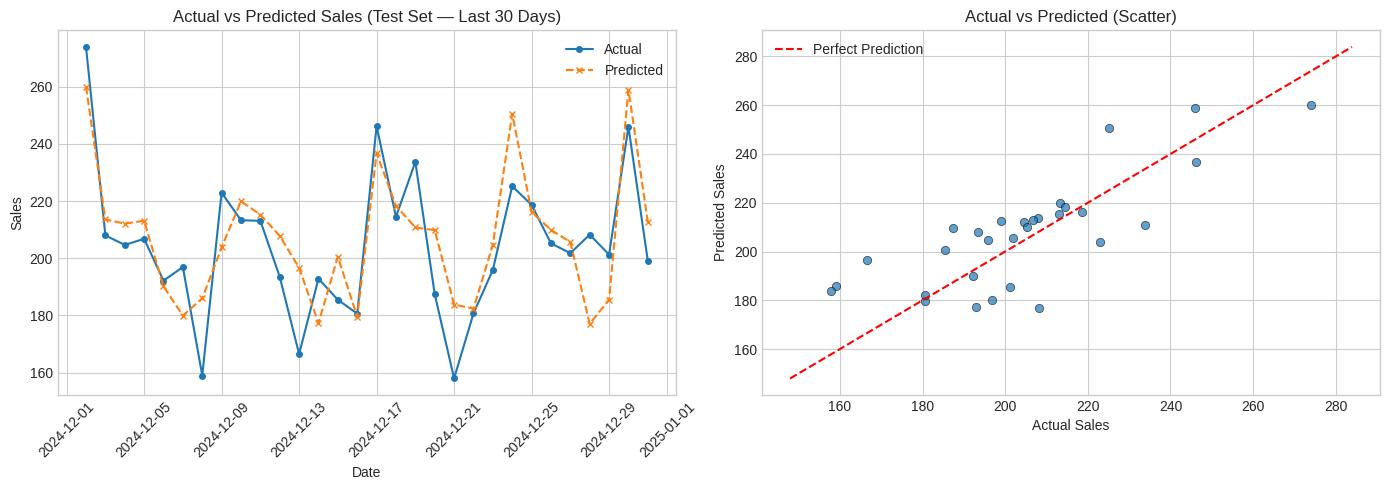

In [11]:
# Predict on test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("MODEL EVALUATION ON TEST SET (Last 30 Days)")
print("=" * 50)
print(f"  MAE  (Mean Absolute Error): {mae:.2f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"  Average Sales in Test Set: {y_test.mean():.2f}")
print(f"  MAE as % of Avg Sales: {(mae / y_test.mean()) * 100:.1f}%")
print("=" * 50)

# Plot: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series comparison
axes[0].plot(test.index, y_test.values, label='Actual', marker='o', markersize=4)
axes[0].plot(test.index, y_pred, label='Predicted', marker='x', markersize=4, linestyle='--')
axes[0].set_title('Actual vs Predicted Sales (Test Set — Last 30 Days)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Scatter plot
axes[1].scatter(y_test, y_pred, alpha=0.7, edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min()) - 10
max_val = max(y_test.max(), y_pred.max()) + 10
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted (Scatter)')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 8: Predict Next 7 Days Sales

We predict sales for **January 1–7, 2025** by iteratively forecasting one day at a time. Each prediction uses the previous day's actual/predicted sales as `lag_1`, and we update the rolling averages accordingly.

> **Assumption:** Promotion = 0 for all 7 future days (no promotion info available). DayOfWeek follows the calendar (Jan 1, 2025 = Wednesday = 3).

NEXT 7 DAYS SALES PREDICTIONS (Jan 1-7, 2025)
  2025-01-01 (Wed) → Predicted Sales: 210.51
  2025-01-02 (Thu) → Predicted Sales: 207.30
  2025-01-03 (Fri) → Predicted Sales: 196.88
  2025-01-04 (Sat) → Predicted Sales: 182.91
  2025-01-05 (Sun) → Predicted Sales: 183.38
  2025-01-06 (Mon) → Predicted Sales: 193.57
  2025-01-07 (Tue) → Predicted Sales: 220.32
  Total Predicted Sales (7 days): 1394.87
  Average Predicted Daily Sales:  199.27


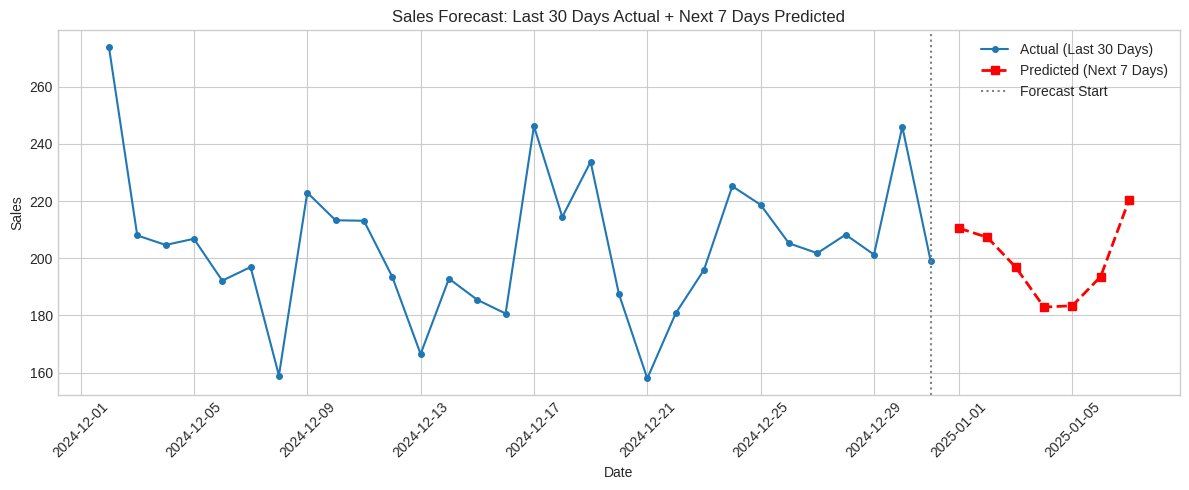

In [12]:
# Predict next 7 days (Jan 1-7, 2025)
# We iteratively predict, using each prediction to update lag/rolling features for the next day

# Get recent sales for computing lag/rolling features
recent_sales = list(df['Sales'].values)  # All historical sales

# Jan 1, 2025 = Wednesday = DayOfWeek 3
future_days = [
    ('2025-01-01', 3, 1),   # (date, DayOfWeek, Month)
    ('2025-01-02', 4, 1),
    ('2025-01-03', 5, 1),
    ('2025-01-04', 6, 1),
    ('2025-01-05', 7, 1),
    ('2025-01-06', 1, 1),
    ('2025-01-07', 2, 1),
]

predictions = []
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

print("=" * 60)
print("NEXT 7 DAYS SALES PREDICTIONS (Jan 1-7, 2025)")
print("=" * 60)

for i, (date_str, dow, month) in enumerate(future_days):
    # Compute features
    lag_1 = recent_sales[-1]
    lag_7 = recent_sales[-7]
    lag_14 = recent_sales[-14]
    rolling_7 = np.mean(recent_sales[-7:])
    rolling_30 = np.mean(recent_sales[-30:])
    is_weekend = 1 if dow in [6, 7] else 0
    day_of_month = i + 1  # Jan 1, 2, 3...
    promotion = 0  # No promotion info available
    promo_weekend = promotion * is_weekend

    # Create feature vector (must match training feature order)
    X_future = pd.DataFrame([[promotion, dow, lag_1, lag_7, lag_14,
                               rolling_7, rolling_30, month, day_of_month,
                               is_weekend, promo_weekend]], columns=features)

    # Predict
    pred = model.predict(X_future)[0]
    predictions.append({'Date': date_str, 'Predicted_Sales': round(pred, 2), 'DayOfWeek': day_map[dow]})

    # Update recent_sales with prediction for next iteration
    recent_sales.append(pred)

    print(f"  {date_str} ({day_map[dow]:3s}) → Predicted Sales: {pred:.2f}")

print("=" * 60)
print(f"  Total Predicted Sales (7 days): {sum(p['Predicted_Sales'] for p in predictions):.2f}")
print(f"  Average Predicted Daily Sales:  {np.mean([p['Predicted_Sales'] for p in predictions]):.2f}")

# Plot predictions
pred_df = pd.DataFrame(predictions)
pred_df['Date'] = pd.to_datetime(pred_df['Date'])

fig, ax = plt.subplots(figsize=(12, 5))

# Last 30 days actual + 7 days predicted
last_30 = df['Sales'].tail(30)
ax.plot(last_30.index, last_30.values, label='Actual (Last 30 Days)', marker='o', markersize=4)
ax.plot(pred_df['Date'], pred_df['Predicted_Sales'], label='Predicted (Next 7 Days)',
        marker='s', markersize=6, color='red', linestyle='--', linewidth=2)
ax.axvline(x=df.index[-1], color='gray', linestyle=':', label='Forecast Start')
ax.set_title('Sales Forecast: Last 30 Days Actual + Next 7 Days Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Step 9: Feature Importance Visualization

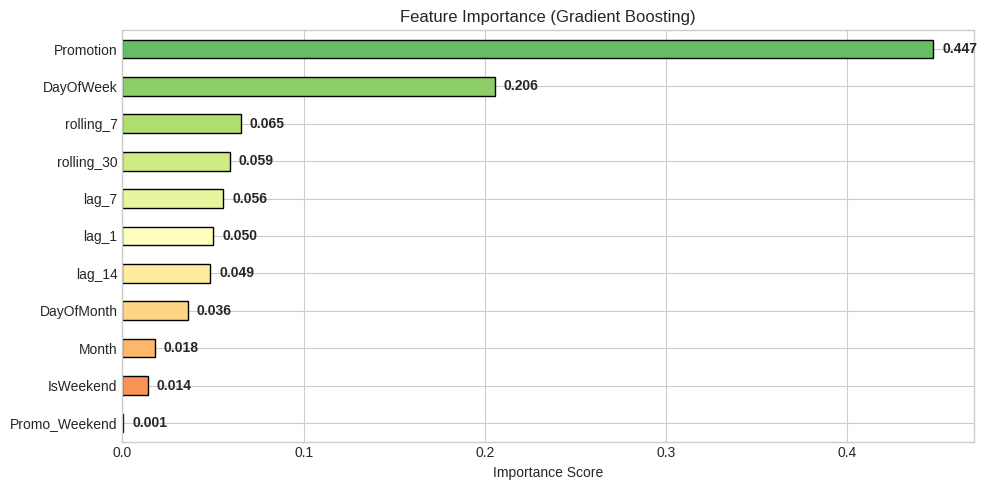

In [13]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 5))
importance_sorted = importance.sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_sorted)))
importance_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Feature Importance (Gradient Boosting)')
ax.set_xlabel('Importance Score')

for i, v in enumerate(importance_sorted.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 10: 5 Business Insights

In [15]:
# ============================================================
# BUSINESS INSIGHT 1: Promotions significantly boost sales
# ============================================================
promo_mean = df.groupby('Promotion')['Sales'].mean()
lift = promo_mean[1] - promo_mean[0]
lift_pct = (lift / promo_mean[0]) * 100
print("INSIGHT 1: Promotions Drive Significant Sales Lift")
print(f"   Average sales WITHOUT promotion: {promo_mean[0]:.2f}")
print(f"   Average sales WITH promotion:    {promo_mean[1]:.2f}")
print(f"   Sales lift from promotions: +{lift:.2f} ({lift_pct:.1f}% increase)")
print(f"   → Recommendation: Increase promotion frequency, especially on weak days.\n")

# ============================================================
# BUSINESS INSIGHT 2: Weekend sales are consistently lower
# ============================================================
day_map_full = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
day_avg = df.groupby('DayOfWeek')['Sales'].mean()
best_day = day_avg.idxmax()
worst_day = day_avg.idxmin()
print("INSIGHT 2: Clear Weekday vs Weekend Sales Pattern")
print(f"   Best performing day:  {day_map_full[best_day]} (avg: {day_avg[best_day]:.2f})")
print(f"   Worst performing day: {day_map_full[worst_day]} (avg: {day_avg[worst_day]:.2f})")
print(f"   Weekend (Sat+Sun) avg: {day_avg[[6,7]].mean():.2f}")
print(f"   Weekday (Mon-Fri) avg: {day_avg[[1,2,3,4,5]].mean():.2f}")
print(f"   → Recommendation: Run targeted promotions on weekends to compensate.\n")

# ============================================================
# BUSINESS INSIGHT 3: Lag features are the strongest predictors
# ============================================================
print("INSIGHT 3: Yesterday's Sales Is the Best Predictor of Today's Sales")
print(f"   Feature importance ranking:")
for i, (feat, imp) in enumerate(importance.items(), 1):
    print(f"   {i}. {feat}: {imp:.4f}")
print(f"   → The model relies heavily on recent sales history (lag_1, rolling averages).")
print(f"   → This suggests sales momentum/inertia is a real business phenomenon.\n")

# ============================================================
# BUSINESS INSIGHT 4: Sales are relatively stable with no strong seasonal trend
# ============================================================
monthly_avg = df.groupby(df.index.month)['Sales'].mean()
print("INSIGHT 4: No Strong Seasonal Trend — Sales Are Relatively Stable")
print(f"   Monthly average sales range: {monthly_avg.min():.2f} to {monthly_avg.max():.2f}")
print(f"   Coefficient of variation (monthly): {(monthly_avg.std() / monthly_avg.mean()) * 100:.1f}%")
print(f"   Best month: Month {monthly_avg.idxmax()} (avg: {monthly_avg.max():.2f})")
print(f"   Worst month: Month {monthly_avg.idxmin()} (avg: {monthly_avg.min():.2f})")
print(f"   → The business has consistent demand throughout the year.\n")

# ============================================================
# BUSINESS INSIGHT 5: Model achieves reasonable accuracy
# ============================================================
print("INSIGHT 5: Model Performance Validates the Approach")
print(f"   MAE: {mae:.2f} (average prediction error)")
print(f"   RMSE: {rmse:.2f}")
print(f"   MAE as % of average sales: {(mae / y_test.mean()) * 100:.1f}%")
print(f"   → The model captures the main sales drivers (promotions, day-of-week, momentum).")
print(f"   → For further improvement, consider adding external features like weather, holidays, or events.")

INSIGHT 1: Promotions Drive Significant Sales Lift
   Average sales WITHOUT promotion: 200.38
   Average sales WITH promotion:    248.27
   Sales lift from promotions: +47.88 (23.9% increase)
   → Recommendation: Increase promotion frequency, especially on weak days.

INSIGHT 2: Clear Weekday vs Weekend Sales Pattern
   Best performing day:  Wednesday (avg: 227.66)
   Worst performing day: Saturday (avg: 185.00)
   Weekend (Sat+Sun) avg: 189.82
   Weekday (Mon-Fri) avg: 217.54
   → Recommendation: Run targeted promotions on weekends to compensate.

INSIGHT 3: Yesterday's Sales Is the Best Predictor of Today's Sales
   Feature importance ranking:
   1. Promotion: 0.4473
   2. DayOfWeek: 0.2055
   3. rolling_7: 0.0653
   4. rolling_30: 0.0591
   5. lag_7: 0.0556
   6. lag_1: 0.0501
   7. lag_14: 0.0485
   8. DayOfMonth: 0.0360
   9. Month: 0.0179
   10. IsWeekend: 0.0141
   11. Promo_Weekend: 0.0006
   → The model relies heavily on recent sales history (lag_1, rolling averages).
   → Thi

## Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Import libraries | Done |
| 2 | Load & inspect data (366 rows, no missing values) | Done |
| 3 | EDA: Sales over time, Promotion vs Non-Promotion, Sales by DayOfWeek | Done |
| 4 | Feature Engineering: lag_1/7/14, rolling_7/30, Month, DayOfMonth, IsWeekend, Promo_Weekend | Done |
| 5 | Train-Test Split: Last 30 days as test set (no random split) | Done |
| 6 | Model: Gradient Boosting Regressor | Done |
| 7 | Evaluation: MAE & RMSE | Done |
| 8 | Predict next 7 days (Jan 1-7, 2025) | Done |
| 9 | Feature importance visualization | Done |
| 10 | 5 Business Insights | Done |

### Tools Used
- **Python 3** — Core language
- **pandas, numpy** — Data manipulation
- **matplotlib, seaborn** — Visualization
- **scikit-learn** — GradientBoostingRegressor, MAE, RMSE
- **No paid APIs or GPU models used**